In [53]:
# Cell 1. Repo path and imports
from pathlib import Path
import sys

repo_root = Path("/data/storage-occ-v2/repos/monte-carlo-selection")
sys.path.insert(0, str(repo_root / "src"))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from occlusion_pipeline.config import PipelineConfig
from occlusion_pipeline.io_utils import latest_jsonl_row
from occlusion_pipeline.modeling import load_model_bundle
from occlusion_pipeline.rendering import render_contour_to_rgb
from occlusion_pipeline.preprocess import rgb_uint8_to_torch
from occlusion_pipeline.inference import run_model
from occlusion_pipeline.occlusion import (
    run_captum_occlusion,
    generate_positions,
    rank_positions_from_occlusion_map,
    apply_multiple_occluders,
    sample_random_positions,
)

In [54]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [55]:
# Cell. Load class names
import json
from pathlib import Path

CLASS_NAMES_JSONL = Path(
    "/data/storage-occ-v2/repos/monte-carlo-selection/data/class_names.jsonl"
)

with CLASS_NAMES_JSONL.open("r", encoding="utf-8") as f:
    classes = [json.loads(line)["class_name"] for line in f if line.strip()]

print("Loaded", len(classes), "class names")
print("First 10:", classes[:10])

Loaded 54 class names
First 10: ['ant', 'bat', 'bear', 'bee', 'beetle', 'bird', 'bug', 'bull', 'butterfly', 'camel']


In [56]:
import torch
import torch.nn.functional as F

def get_class_name(idx, classes):
    if classes is None:
        return str(idx)
    if idx < 0 or idx >= len(classes):
        return f"idx_{idx}"
    return classes[idx]

def compute_stride_fixed(size, stride=1):
    return int(stride)

def generate_positions(h, w, size, stride):
    ys = list(range(0, max(1, h - size + 1), stride))
    xs = list(range(0, max(1, w - size + 1), stride))

    if ys[-1] != h - size:
        ys.append(h - size)
    if xs[-1] != w - size:
        xs.append(w - size)

    positions = []
    for y0 in ys:
        for x0 in xs:
            positions.append((y0, x0))
    return positions

def apply_single_occluder(x, y0, x0, size, baseline_value=0.0):
    x_occ = x.clone()
    x_occ[:, :, y0:y0+size, x0:x0+size] = baseline_value
    return x_occ

def apply_multiple_occluders(x, coords, size, baseline_value=0.0):
    x_occ = x.clone()
    for (y0, x0) in coords:
        x_occ[:, :, y0:y0+size, x0:x0+size] = baseline_value
    return x_occ

def sample_random_positions(all_positions, k, patch_size, rng, allow_overlap=False):
    all_positions = list(all_positions)
    rng.shuffle(all_positions)

    chosen = []

    def overlaps_existing(y, x):
        for yy, xx in chosen:
            if not (
                x + patch_size <= xx or xx + patch_size <= x or
                y + patch_size <= yy or yy + patch_size <= y
            ):
                return True
        return False

    for y0, x0 in all_positions:
        if allow_overlap or not overlaps_existing(y0, x0):
            chosen.append((y0, x0))
        if len(chosen) >= k:
            break

    if len(chosen) < k:
        raise RuntimeError("Could not sample enough random positions.")

    return chosen

def normalize_for_display(arr):
    arr = np.asarray(arr, dtype=float)
    a = np.nanmin(arr)
    b = np.nanmax(arr)
    if np.isclose(a, b):
        return np.zeros_like(arr)
    return (arr - a) / (b - a)

In [57]:
# Cell. Update config for full sweep
cfg = PipelineConfig(
    occluder_sizes=[8, 16, 32, 64],
    max_num_occluders=8,
    stride_fraction=0.5,   # ignored below because we force stride=1
    baseline_value=0.0,
)
cfg.ensure_dirs()

In [58]:
from pathlib import Path

case_jsonl_path = Path(
    "/data/storage-occ-v2/repos/monte-carlo-selection/data/cases/occlusion/s_bird_17/generated/s_bird_17.jsonl"
)

model_paths = {
    "shape_biased": Path(
        "/data/storage-occ-v2/repos/monte-carlo-selection/data/models/resnet50_geirhos_tl.onnx"
    ),
    "texture_biased": Path(
        "/data/storage-occ-v2/repos/monte-carlo-selection/data/models/resnet50_tl_20250829.onnx"
    ),
}

bundles = {
    model_type: load_model_bundle(model_type, model_path, device=DEVICE)
    for model_type, model_path in model_paths.items()
}

print("case_jsonl_path:", case_jsonl_path)
print("loaded bundles:", list(bundles.keys()))
for model_type, bundle in bundles.items():
    print(model_type, "input_hw:", bundle.input_hw)

case_jsonl_path: /data/storage-occ-v2/repos/monte-carlo-selection/data/cases/occlusion/s_bird_17/generated/s_bird_17.jsonl
loaded bundles: ['shape_biased', 'texture_biased']
shape_biased input_hw: (224, 224)
texture_biased input_hw: (224, 224)


In [59]:
row = latest_jsonl_row(case_jsonl_path)

case_id = case_jsonl_path.stem
contour_xy = np.asarray(row["shape_contour_xy"], dtype=np.float32)
invert_yaxis = bool(row.get("plotting", {}).get("invert_yaxis", True))

for model_type, bundle in bundles.items():
    input_h, input_w = bundle.input_hw
    assert input_h == input_w

    image_rgb = render_contour_to_rgb(
        contour_xy=contour_xy,
        image_size=input_h,
        line_width=cfg.line_width,
        invert_yaxis=invert_yaxis,
    )

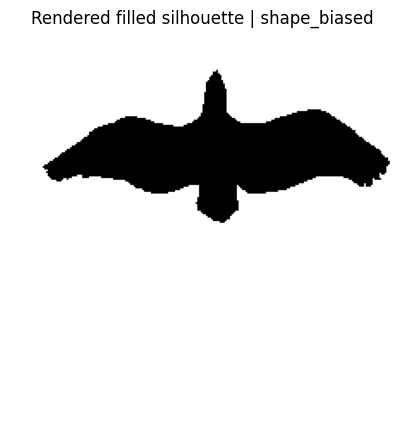

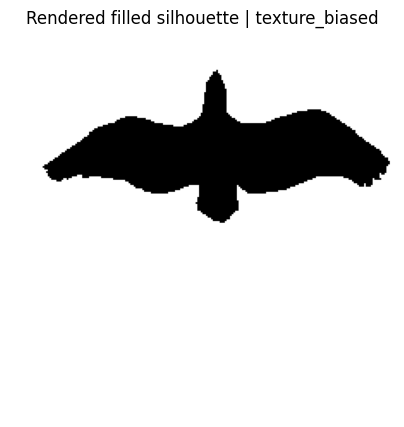

In [60]:
# Cell 5. Render the filled silhouette for both models
rendered_images = {}

for model_type, bundle in bundles.items():
    input_h, input_w = bundle.input_hw
    assert input_h == input_w

    image_rgb = render_contour_to_rgb(
        contour_xy=contour_xy,
        image_size=input_h,
        line_width=cfg.line_width,
        invert_yaxis=invert_yaxis,
    )
    rendered_images[model_type] = image_rgb

    plt.figure(figsize=(5, 5))
    plt.imshow(image_rgb)
    plt.title(f"Rendered filled silhouette | {model_type}")
    plt.axis("off")
    plt.show()

In [61]:
# Cell 6. Build model inputs for both models
inputs = {}

for model_type, bundle in bundles.items():
    input_h, input_w = bundle.input_hw
    image_rgb = rendered_images[model_type]

    x = rgb_uint8_to_torch(
        image_rgb=image_rgb,
        image_size=input_h,
        mean=cfg.mean,
        std=cfg.std,
        device=DEVICE,
    )
    inputs[model_type] = x

    print(model_type, "input tensor shape:", tuple(x.shape))

shape_biased input tensor shape: (1, 3, 224, 224)
texture_biased input tensor shape: (1, 3, 224, 224)


In [62]:
# Cell. Baseline predictions for both models with class names and top-5
baseline_results = {}

for model_type, bundle in bundles.items():
    x = inputs[model_type]
    baseline = run_model(bundle, x)

    logits = baseline["logits"]
    probs = baseline["probs"]

    summary = summarize_prediction(logits, probs, classes=classes, topk=5)

    baseline_results[model_type] = {
        "pred_class": summary["pred_idx"],
        "pred_class_name": summary["pred_class_name"],
        "target_logit": summary["pred_logit"],
        "confidence": summary["pred_prob"],
        "logits": logits,
        "probs": probs,
        "topk": summary["topk"],
    }

    print(f"\n=== {model_type} ===")
    print("baseline_target_class_idx:", summary["pred_idx"])
    print("baseline_target_class_name:", summary["pred_class_name"])
    print("baseline_target_logit:", summary["pred_logit"])
    print("baseline_confidence:", summary["pred_prob"])
    print("Top 5:")
    for i, item in enumerate(summary["topk"], start=1):
        print(
            f"  {i}. {item['class_name']} "
            f"(idx={item['idx']}, prob={item['prob']:.4f}, logit={item['logit']:.4f})"
        )


=== shape_biased ===
baseline_target_class_idx: 5
baseline_target_class_name: bird
baseline_target_logit: 5.135880470275879
baseline_confidence: 0.27608194947242737
Top 5:
  1. bird (idx=5, prob=0.2761, logit=5.1359)
  2. dolphin (idx=18, prob=0.2197, logit=4.9075)
  3. hawk (idx=28, prob=0.1386, logit=4.4470)
  4. eagle (idx=20, prob=0.0854, logit=3.9628)
  5. bat (idx=1, prob=0.0756, logit=3.8404)

=== texture_biased ===
baseline_target_class_idx: 17
baseline_target_class_name: dog
baseline_target_logit: 160.50514221191406
baseline_confidence: 1.0
Top 5:
  1. dog (idx=17, prob=1.0000, logit=160.5051)
  2. shark (idx=41, prob=0.0000, logit=128.2406)
  3. fish (idx=22, prob=0.0000, logit=108.8522)
  4. butterfly (idx=8, prob=0.0000, logit=108.7347)
  5. cat (idx=10, prob=0.0000, logit=107.4262)


In [63]:
# Cell. Demo-friendly stage-1 manual single-window sweep across 8,16,32,64
single_window_rows = []

for model_type, bundle in bundles.items():
    x = inputs[model_type]
    baseline_target_class = baseline_results[model_type]["pred_class"]
    baseline_target_class_name = baseline_results[model_type]["pred_class_name"]
    baseline_target_logit = baseline_results[model_type]["target_logit"]
    baseline_confidence = baseline_results[model_type]["confidence"]

    input_h, input_w = bundle.input_hw

    for occluder_size in [8, 16, 32, 64]:
        stride = max(1, int(round(occluder_size * 0.5)))
        positions = generate_positions(
            h=input_h,
            w=input_w,
            size=occluder_size,
            stride=stride,
        )

        print(f"{model_type} | size={occluder_size} | stride={stride} | n_positions={len(positions)}")

        for y0, x0 in positions:
            x_occ = apply_single_occluder(
                x=x,
                y0=y0,
                x0=x0,
                size=occluder_size,
                baseline_value=cfg.baseline_value,
            )

            post = run_model(bundle, x_occ)
            post_pred_class = int(post["pred_class"])
            post_pred_class_name = get_class_name(post_pred_class, classes)
            post_target_logit = float(post["logits"][0, baseline_target_class].item())
            post_confidence = float(post["pred_prob"])

            single_window_rows.append({
                "case_id": case_id,
                "model_type": model_type,
                "occluder_size": occluder_size,
                "stride": stride,
                "y0": y0,
                "x0": x0,
                "y_center": y0 + occluder_size / 2.0,
                "x_center": x0 + occluder_size / 2.0,
                "baseline_pred_class": baseline_target_class,
                "baseline_pred_class_name": baseline_target_class_name,
                "post_occlusion_pred_class": post_pred_class,
                "post_occlusion_pred_class_name": post_pred_class_name,
                "baseline_target_logit": baseline_target_logit,
                "post_occlusion_target_logit": post_target_logit,
                "target_logit_drop": baseline_target_logit - post_target_logit,
                "baseline_confidence": baseline_confidence,
                "post_occlusion_confidence": post_confidence,
                "prediction_changed": int(post_pred_class != baseline_target_class),
                "baseline_class_still_top1": int(post_pred_class == baseline_target_class),
            })

len(single_window_rows)

shape_biased | size=8 | stride=4 | n_positions=3025
shape_biased | size=16 | stride=8 | n_positions=729
shape_biased | size=32 | stride=16 | n_positions=169
shape_biased | size=64 | stride=32 | n_positions=36
texture_biased | size=8 | stride=4 | n_positions=3025
texture_biased | size=16 | stride=8 | n_positions=729
texture_biased | size=32 | stride=16 | n_positions=169
texture_biased | size=64 | stride=32 | n_positions=36


7918

In [64]:
import pandas as pd

single_window_df = pd.DataFrame(single_window_rows)
display(single_window_df.head())
print("n rows:", len(single_window_df))

,case_id,model_type,occluder_size,stride,y0,x0,y_center,x_center,baseline_pred_class,baseline_pred_class_name,post_occlusion_pred_class,post_occlusion_pred_class_name,baseline_target_logit,post_occlusion_target_logit,target_logit_drop,baseline_confidence,post_occlusion_confidence,prediction_changed,baseline_class_still_top1
0,s_bird_17,shape_biased,8,4,0,0,4.0,4.0,5,bird,18,dolphin,5.13588,4.755110,0.380770,0.276082,0.248580,1,0
1,s_bird_17,shape_biased,8,4,0,4,4.0,8.0,5,bird,18,dolphin,5.13588,4.778313,0.357568,0.276082,0.253152,1,0
2,s_bird_17,shape_biased,8,4,0,8,4.0,12.0,5,bird,18,dolphin,5.13588,4.765613,0.370268,0.276082,0.264682,1,0
3,s_bird_17,shape_biased,8,4,0,12,4.0,16.0,5,bird,18,dolphin,5.13588,4.793072,0.342809,0.276082,0.263632,1,0
4,s_bird_17,shape_biased,8,4,0,16,4.0,20.0,5,bird,18,dolphin,5.13588,4.750139,0.385741,0.276082,0.275118,1,0


n rows: 7918


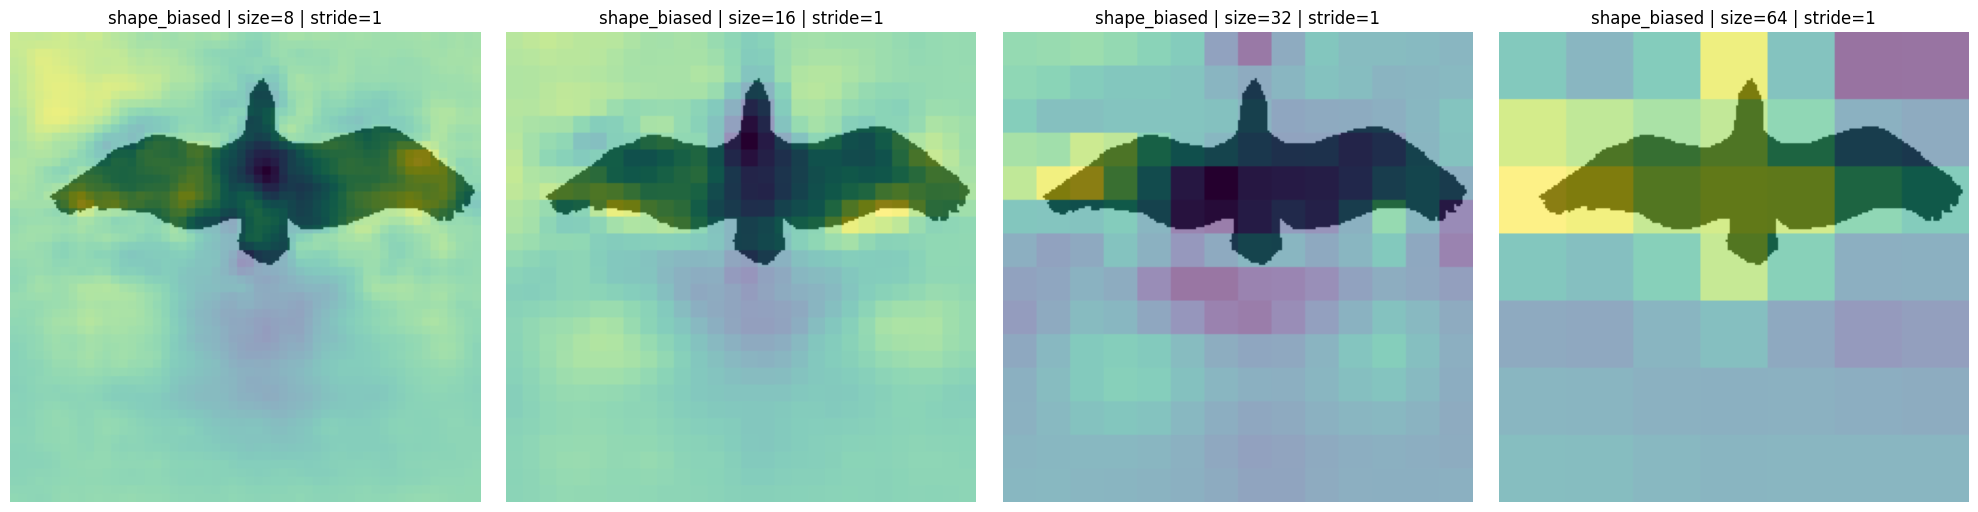

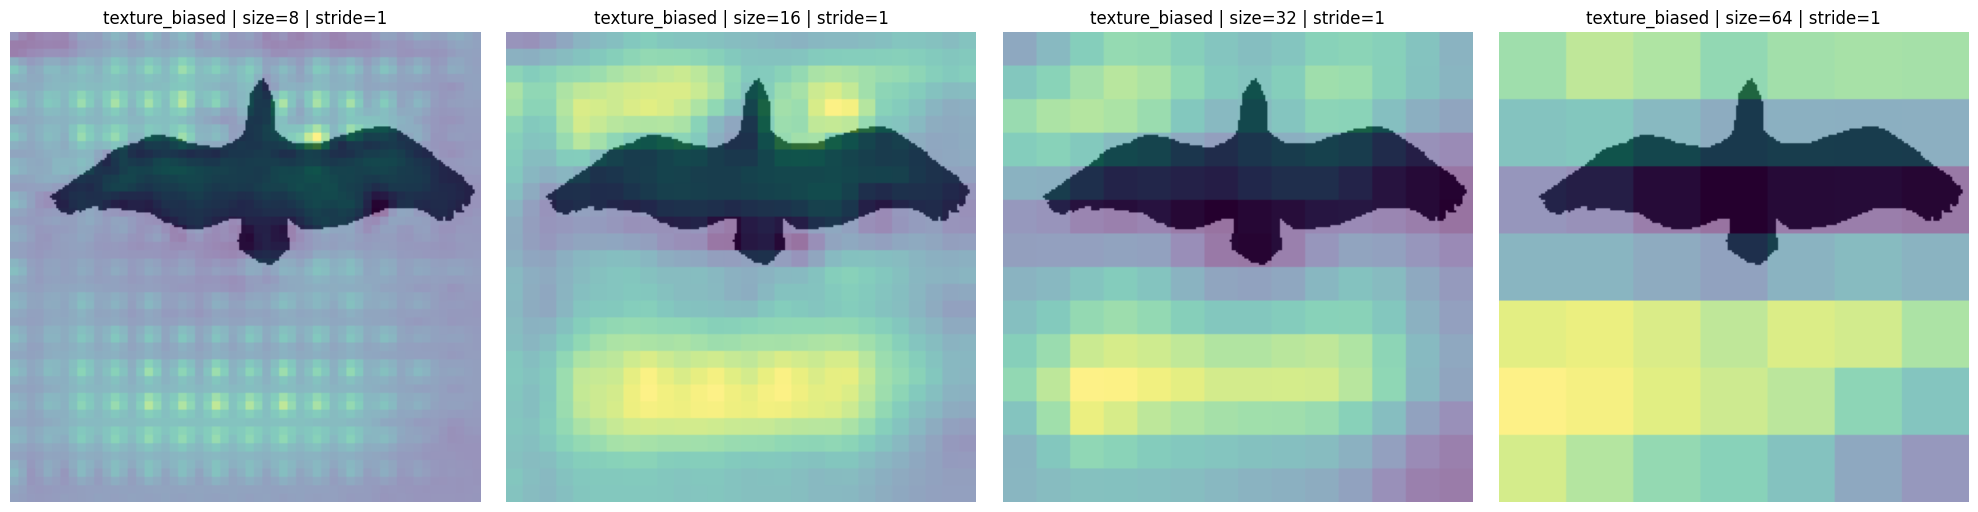

In [65]:
for model_type, bundle in bundles.items():
    image_rgb = rendered_images[model_type]
    input_h, input_w = bundle.input_hw

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, occluder_size in zip(axes, [8, 16, 32, 64]):
        subdf = single_window_df[
            (single_window_df["model_type"] == model_type) &
            (single_window_df["occluder_size"] == occluder_size)
        ].copy()

        heat = np.full((input_h, input_w), np.nan, dtype=float)
        count = np.zeros((input_h, input_w), dtype=float)

        for _, r in subdf.iterrows():
            y0 = int(r["y0"])
            x0 = int(r["x0"])
            val = float(r["target_logit_drop"])

            block = np.nan_to_num(heat[y0:y0+occluder_size, x0:x0+occluder_size], nan=0.0)
            heat[y0:y0+occluder_size, x0:x0+occluder_size] = block + val
            count[y0:y0+occluder_size, x0:x0+occluder_size] += 1

        heat = heat / np.where(count == 0, np.nan, count)

        ax.imshow(image_rgb)
        ax.imshow(normalize_for_display(heat), alpha=0.55)
        ax.set_title(f"{model_type} | size={occluder_size} | stride=1")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [66]:
ranked_positions = {}

for model_type in bundles.keys():
    ranked_positions[model_type] = {}

    for occluder_size in [8, 16, 32, 64]:
        subdf = (
            single_window_df[
                (single_window_df["model_type"] == model_type) &
                (single_window_df["occluder_size"] == occluder_size)
            ]
            .sort_values(["target_logit_drop", "y0", "x0"], ascending=[False, True, True])
            .copy()
        )

        all_positions = list(zip(subdf["y0"].astype(int), subdf["x0"].astype(int)))

        chosen = []

        def overlaps_existing(y, x):
            for yy, xx in chosen:
                if not (
                    x + occluder_size <= xx or xx + occluder_size <= x or
                    y + occluder_size <= yy or yy + occluder_size <= y
                ):
                    return True
            return False

        for _, r in subdf.iterrows():
            y0 = int(r["y0"])
            x0 = int(r["x0"])
            if not overlaps_existing(y0, x0):
                chosen.append((y0, x0))

        ranked_positions[model_type][occluder_size] = {
            "all_positions": all_positions,
            "targeted_positions_ranked": chosen,
            "position_table": subdf,
        }

        print(
            model_type,
            "| size:", occluder_size,
            "| top 10 targeted:", chosen[:10]
        )

shape_biased | size: 8 | top 10 targeted: [(56, 192), (80, 32), (76, 188), (32, 16), (36, 24), (56, 184), (24, 20), (60, 200), (40, 16), (72, 84)]
shape_biased | size: 16 | top 10 targeted: [(80, 160), (80, 176), (72, 48), (64, 16), (40, 64), (72, 32), (48, 184), (56, 200), (72, 192), (64, 0)]
shape_biased | size: 32 | top 10 targeted: [(48, 32), (48, 0), (80, 48), (80, 160), (0, 32), (80, 128), (0, 0), (32, 64), (128, 176), (160, 48)]
shape_biased | size: 64 | top 10 targeted: [(32, 32), (64, 96), (0, 96), (32, 160), (160, 0), (160, 128), (160, 64), (96, 0), (96, 160)]
texture_biased | size: 8 | top 10 targeted: [(48, 144), (28, 76), (172, 96), (172, 128), (28, 144), (44, 80), (32, 124), (172, 64), (176, 108), (28, 60)]
texture_biased | size: 16 | top 10 targeted: [(32, 160), (160, 64), (160, 96), (160, 128), (32, 144), (168, 80), (168, 112), (176, 64), (176, 96), (168, 144)]
texture_biased | size: 32 | top 10 targeted: [(160, 32), (144, 64), (16, 48), (16, 144), (144, 128), (16, 16),

In [67]:
demo_rows = []
rng = np.random.default_rng(cfg.seed)

for model_type, bundle in bundles.items():
    x = inputs[model_type]
    baseline_target_class = baseline_results[model_type]["pred_class"]
    baseline_target_class_name = baseline_results[model_type]["pred_class_name"]
    baseline_target_logit = baseline_results[model_type]["target_logit"]
    baseline_confidence = baseline_results[model_type]["confidence"]

    for occluder_size in [8, 16, 32, 64]:
        all_positions = ranked_positions[model_type][occluder_size]["all_positions"]
        targeted_ranked = ranked_positions[model_type][occluder_size]["targeted_positions_ranked"]

        for placement_type in ["targeted", "random"]:
            for num_occluders in range(1, 9):
                if placement_type == "targeted":
                    chosen_positions = targeted_ranked[:num_occluders]
                else:
                    chosen_positions = sample_random_positions(
                        all_positions=all_positions,
                        k=num_occluders,
                        patch_size=occluder_size,
                        rng=rng,
                        allow_overlap=False,
                    )

                x_occ = apply_multiple_occluders(
                    x=x,
                    coords=chosen_positions,
                    size=occluder_size,
                    baseline_value=cfg.baseline_value,
                )

                post = run_model(bundle, x_occ)
                post_pred_class = int(post["pred_class"])
                post_pred_class_name = get_class_name(post_pred_class, classes)
                post_target_logit = float(post["logits"][0, baseline_target_class].item())
                post_confidence = float(post["pred_prob"])

                demo_rows.append({
                    "case_id": case_id,
                    "model_type": model_type,
                    "occluder_size": occluder_size,
                    "stride": 1,
                    "placement_type": placement_type,
                    "num_occluders": num_occluders,
                    "baseline_target_logit": baseline_target_logit,
                    "post_occlusion_target_logit": post_target_logit,
                    "target_logit_drop": baseline_target_logit - post_target_logit,
                    "baseline_pred_class": baseline_target_class,
                    "baseline_pred_class_name": baseline_target_class_name,
                    "post_occlusion_pred_class": post_pred_class,
                    "post_occlusion_pred_class_name": post_pred_class_name,
                    "baseline_confidence": baseline_confidence,
                    "post_occlusion_confidence": post_confidence,
                })

demo_df = pd.DataFrame(demo_rows)
display(demo_df.head(20))
print("n rows:", len(demo_df))

,case_id,model_type,occluder_size,stride,placement_type,num_occluders,baseline_target_logit,post_occlusion_target_logit,target_logit_drop,baseline_pred_class,baseline_pred_class_name,post_occlusion_pred_class,post_occlusion_pred_class_name,baseline_confidence,post_occlusion_confidence
0,s_bird_17,shape_biased,8,1,targeted,1,5.13588,4.410230,0.725651,5,bird,18,dolphin,0.276082,0.282588
1,s_bird_17,shape_biased,8,1,targeted,2,5.13588,3.714567,1.421313,5,bird,18,dolphin,0.276082,0.341851
2,s_bird_17,shape_biased,8,1,targeted,3,5.13588,3.369976,1.765905,5,bird,18,dolphin,0.276082,0.302287
3,s_bird_17,shape_biased,8,1,targeted,4,5.13588,2.900785,2.235095,5,bird,18,dolphin,0.276082,0.326839
4,s_bird_17,shape_biased,8,1,targeted,5,5.13588,2.909536,2.226345,5,bird,18,dolphin,0.276082,0.335849
5,s_bird_17,shape_biased,8,1,targeted,6,5.13588,3.342457,1.793424,5,bird,18,dolphin,0.276082,0.330457
6,s_bird_17,shape_biased,8,1,targeted,7,5.13588,3.294528,1.841353,5,bird,18,dolphin,0.276082,0.340980
7,s_bird_17,shape_biased,8,1,targeted,8,5.13588,3.322767,1.813114,5,bird,18,dolphin,0.276082,0.338960
8,s_bird_17,shape_biased,8,1,random,1,5.13588,5.201065,-0.065184,5,bird,5,bird,0.276082,0.274475
9,s_bird_17,shape_biased,8,1,random,2,5.13588,5.118855,0.017025,5,bird,5,bird,0.276082,0.270749


n rows: 128


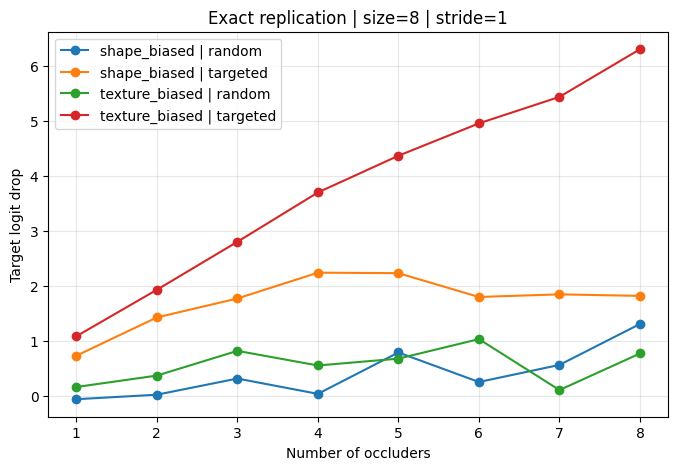

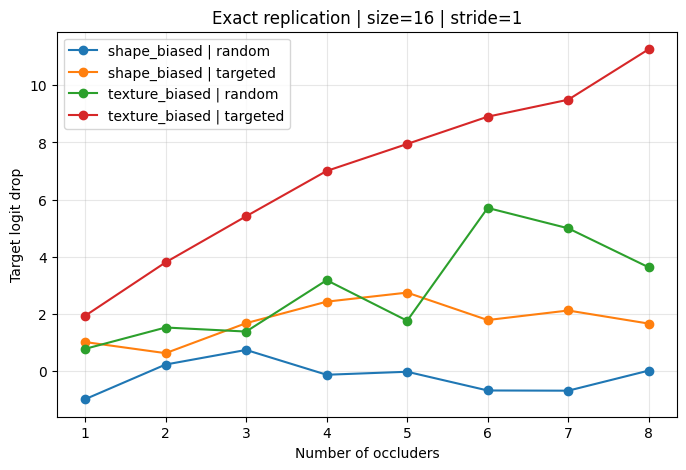

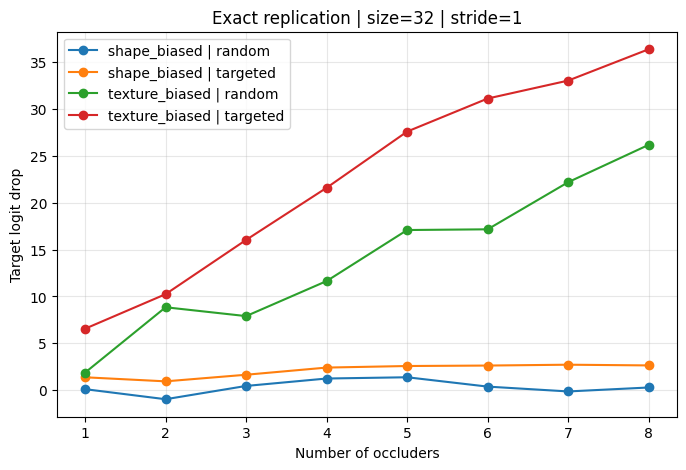

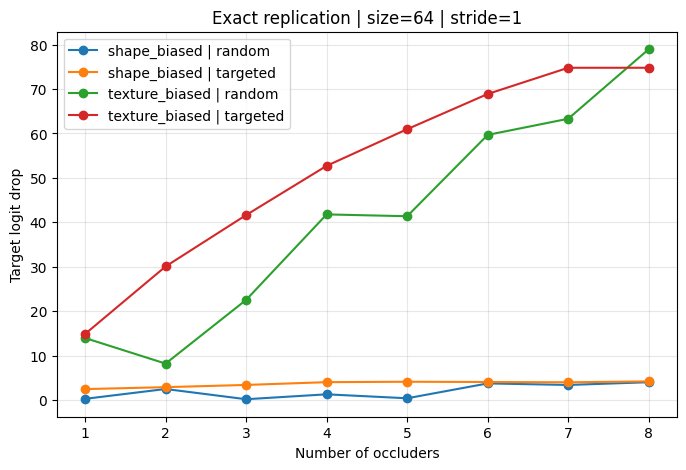

In [68]:
for occluder_size in [8, 16, 32, 64]:
    subdf_all = demo_df[demo_df["occluder_size"] == occluder_size].copy()

    plt.figure(figsize=(8, 5))
    for (model_type, placement_type), subdf in subdf_all.groupby(["model_type", "placement_type"]):
        subdf = subdf.sort_values("num_occluders")
        plt.plot(
            subdf["num_occluders"],
            subdf["target_logit_drop"],
            marker="o",
            label=f"{model_type} | {placement_type}",
        )

    plt.xlabel("Number of occluders")
    plt.ylabel("Target logit drop")
    plt.title(f"Exact replication | size={occluder_size} | stride=1")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [69]:
results_dir = Path("/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_demo_exact")
results_dir.mkdir(parents=True, exist_ok=True)

single_window_csv = results_dir / "single_window_position_level_results.csv"
multi_occluder_csv = results_dir / "multi_occluder_targeted_vs_random_results.csv"

single_window_df.to_csv(single_window_csv, index=False)
demo_df.to_csv(multi_occluder_csv, index=False)

print("Saved single-window results to:", single_window_csv)
print("Saved multi-occluder results to:", multi_occluder_csv)

Saved single-window results to: /data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_demo_exact/single_window_position_level_results.csv
Saved multi-occluder results to: /data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_demo_exact/multi_occluder_targeted_vs_random_results.csv
